In [58]:
import pandas as pd
import polars as pl
import numpy as np

from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve

import matplotlib.pyplot as plt
import seaborn as sns

In [105]:
panel = pl.read_parquet('../data/wages_working_data.parquet')
panel = panel.filter(
    pl.col('total_income') < 100_000
)
panel = (
    panel
    .with_columns(gender = pl.when(pl.col('gender') == 'MALE').then(1).otherwise(0))
    .with_columns(recieves_pension = pl.when(pl.col('recieves_pension') == 'Yes').then(1).otherwise(0))
    .with_columns(recieves_pension_30days = pl.when(pl.col('recieves_pension_30days') == 'Yes').then(1).otherwise(0))
    .with_columns(income_decrease_bc_covid = pl.when(pl.col('income_decrease_bc_covid') == 'Yes').then(1).otherwise(0))
    .with_columns(pl.col('disability_class').str.replace(' ', '_').str.to_lowercase())
    .to_dummies('disability_class', drop_nulls=True, drop_first=True)
    .with_columns(has_disability = pl.when(pl.col('has_disability') == 'Yes').then(1).otherwise(0))
    .with_columns(male_retiered = pl.when(
        (pl.col('gender') == 1) & (pl.col('age') >= 65)
    ).then(1).otherwise(0))
    .with_columns(female_retiered = pl.when(
        (pl.col('gender') == 0) & (pl.col('age') >= 60)
    ).then(1).otherwise(0))
    .with_columns(is_retired = pl.col('male_retiered') + pl.col('female_retiered'))
    .to_dummies('educ_level', drop_nulls=True).drop('educ_level_common')
).to_pandas()[[
 #'recieves_pension',
 # 'amount_pension',
 # 'iea_income',
 # 'total_income',
 #'amount_unemp_benefits',
 'income_decrease_bc_covid',
 'hearing_disability',
 'eye_disability',
 'spinal_disability',
 'neuro_disability',
 'has_disability',
 #'region',
 #'habitat',
 # 'psu',
 'age',
 'educ_level_higher',
 'educ_level_school_or_less',
 'educ_level_university',
 # 'educ',
 # 'marst',
 'gender',
 'is_employed',
 #'wages',
 'is_married',
 'is_female',
 'is_retired'
]].dropna()
panel

,income_decrease_bc_covid,hearing_disability,eye_disability,spinal_disability,neuro_disability,has_disability,age,educ_level_higher,educ_level_school_or_less,educ_level_university,gender,is_employed,is_married,is_female,is_retired
0,0,0,0,0,0,0,46.0,1,0,0,0,0,0,1,0
1,1,0,0,0,0,0,49.0,1,0,0,0,1,0,1,0
2,0,0,0,0,0,0,50.0,1,0,0,0,1,0,1,0
3,0,0,0,0,0,0,38.5,0,0,1,0,1,0,1,0
4,0,0,0,0,0,0,43.5,0,0,1,0,1,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13509,0,0,0,0,0,0,47.0,0,0,1,0,1,0,1,0
13510,1,0,0,0,0,0,46.5,0,0,0,0,1,1,1,0
13511,0,0,0,0,0,0,47.5,0,0,0,0,1,1,1,0
13512,0,0,0,1,0,0,45.0,0,0,0,1,1,1,0,0


In [106]:
X = panel.drop(columns='has_disability').to_numpy()
y = panel['has_disability'].to_numpy()

In [107]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y
)

In [108]:
feature_names = list(panel.drop(columns='has_disability').columns)
feature_names

['income_decrease_bc_covid',
 'hearing_disability',
 'eye_disability',
 'spinal_disability',
 'neuro_disability',
 'age',
 'educ_level_higher',
 'educ_level_school_or_less',
 'educ_level_university',
 'gender',
 'is_employed',
 'is_married',
 'is_female',
 'is_retired']

In [109]:
categorical_features = [
 'region',
 'habitat',
 'psu',
 'educ',
 'marst'
]
categorical_features

['region', 'habitat', 'psu', 'educ', 'marst']

In [110]:
model = CatBoostClassifier(
    iterations=500,           # Number of trees
    learning_rate=0.05,      # Learning rate
    depth=6,                 # Tree depth
    loss_function='Logloss', # Binary classification loss
    eval_metric='AUC',       # Evaluation metric
    random_seed=42,
    verbose=False,           # Set to True to see training logs
    early_stopping_rounds=50 # Stop if no improvement
)

In [111]:
model.fit(
    X_train, y_train,
    #cat_features=categorical_features,  # <-- THIS FIXES THE ERROR
    eval_set=(X_test, y_test),
    verbose=False
)

CatBoostClassifier(depth=6, early_stopping_rounds=50, eval_metric='AUC', iterations=500, learning_rate=0.05, loss_function='Logloss', random_seed=42, verbose=False)

In [112]:
# train_pool = Pool(X_train, y_train, feature_names=feature_names)
# test_pool = Pool(X_test, y_test, feature_names=feature_names)

In [113]:
y_pred_proba = model.predict_proba(X_test)[:, 1]  # Probability of class 1
y_pred = (y_pred_proba > 0.5).astype(int)        # Binary predictions


accuracy = accuracy_score(y_test, y_pred)
auc_score = roc_auc_score(y_test, y_pred_proba)

In [114]:
accuracy

0.9811320754716981

In [115]:
auc_score

0.8888870149495386

In [116]:
cm = confusion_matrix(y_test, y_pred)
feature_importance = model.get_feature_importance()
feature_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importance
}).sort_values('importance', ascending=False)
feature_importance_df

,feature,importance
5,age,27.367482
11,is_married,13.226491
9,gender,9.961488
12,is_female,9.286972
8,educ_level_university,8.714204
2,eye_disability,7.915795
3,spinal_disability,5.500007
10,is_employed,5.291645
4,neuro_disability,4.789619
6,educ_level_higher,3.764678


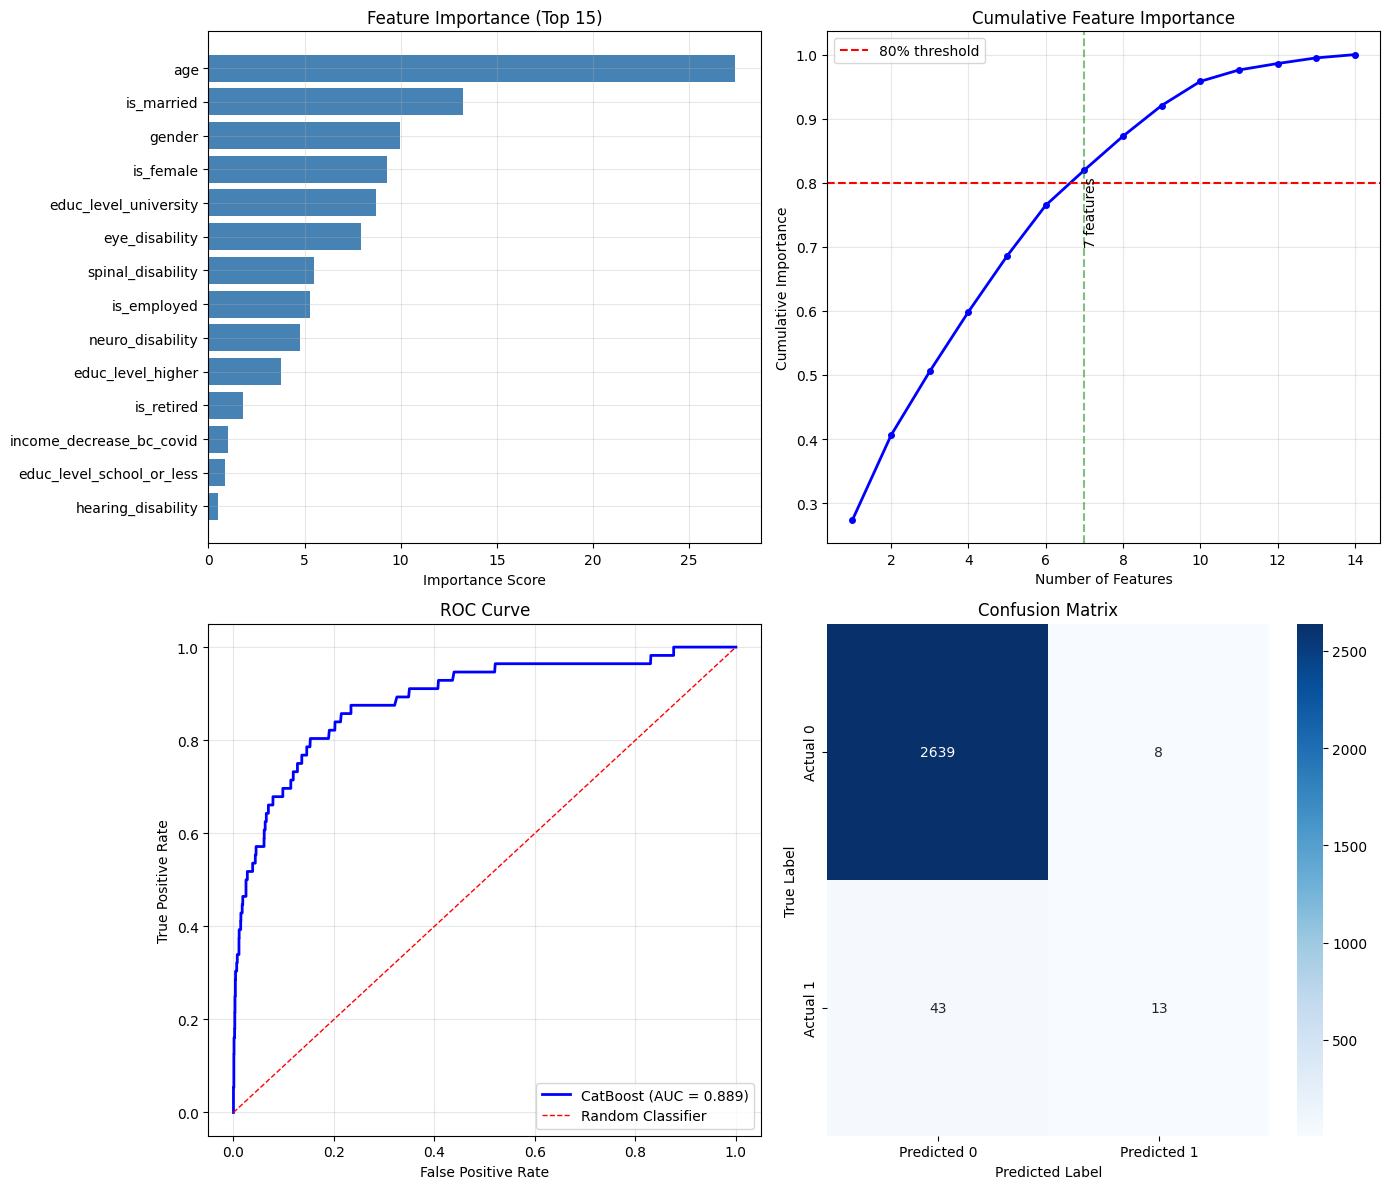

In [117]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Plot 1: Feature importance bar plot
ax1 = axes[0, 0]
top_features = feature_importance_df.head(15)
ax1.barh(top_features['feature'], top_features['importance'], color='steelblue')
ax1.set_xlabel('Importance Score')
ax1.set_title('Feature Importance (Top 15)')
ax1.invert_yaxis()  # Highest importance at top
ax1.grid(True, alpha=0.3)

# Plot 2: Cumulative feature importance
ax2 = axes[0, 1]
cumulative_importance = feature_importance_df['importance'].cumsum() / feature_importance_df['importance'].sum()
ax2.plot(range(1, len(cumulative_importance) + 1), cumulative_importance, 'bo-', linewidth=2, markersize=4)
ax2.axhline(y=0.8, color='red', linestyle='--', label='80% threshold')
ax2.set_xlabel('Number of Features')
ax2.set_ylabel('Cumulative Importance')
ax2.set_title('Cumulative Feature Importance')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Highlight threshold
n_features_80 = np.where(cumulative_importance >= 0.8)[0][0] + 1
ax2.axvline(x=n_features_80, color='green', linestyle='--', alpha=0.5)
ax2.text(n_features_80, 0.7, f'{n_features_80} features', rotation=90, verticalalignment='bottom')

# Plot 3: ROC Curve
ax3 = axes[1, 0]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
ax3.plot(fpr, tpr, 'b-', linewidth=2, label=f'CatBoost (AUC = {auc_score:.3f})')
ax3.plot([0, 1], [0, 1], 'r--', linewidth=1, label='Random Classifier')
ax3.set_xlabel('False Positive Rate')
ax3.set_ylabel('True Positive Rate')
ax3.set_title('ROC Curve')
ax3.legend(loc='lower right')
ax3.grid(True, alpha=0.3)

# Plot 4: Confusion Matrix Heatmap
ax4 = axes[1, 1]
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax4, 
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
ax4.set_title('Confusion Matrix')
ax4.set_ylabel('True Label')
ax4.set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()